C:\Users\tsift\AppData\Local\Temp\ipykernel_10052\2494108892.py:18: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])


Rows before bin filter: 1529350, after: 1529350, dropped: 0


C:\Users\tsift\AppData\Local\Temp\ipykernel_10052\2494108892.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  homes_per_bin = df_fa.groupby("floor_area_bin")["home_id"].nunique().reindex(labels)



Homes per floor area bin:
 floor_area_bin
Small (<60 m²)         52
Medium (60–120 m²)    169
Large (>120 m²)        33
Name: home_id, dtype: int64

Rows per floor area bin:
 floor_area_bin
Small (<60 m²)         291971
Medium (60–120 m²)    1006836
Large (>120 m²)        230543
Name: count, dtype: int64


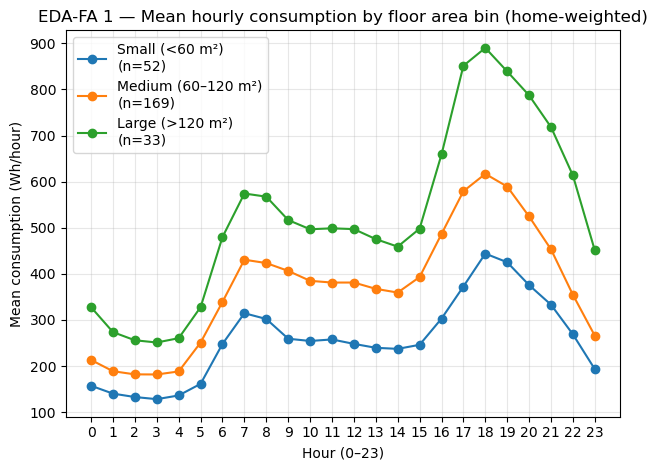

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_residents_floorarea\EDA_FA_01_mean_consumption_by_hour_weighted.png


C:\Users\tsift\AppData\Local\Temp\ipykernel_10052\2494108892.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_fa.groupby(["home_id", "floor_area_bin", "date"])["consumption_Wh"]
C:\Users\tsift\AppData\Local\Temp\ipykernel_10052\2494108892.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily.groupby(["home_id", "floor_area_bin"])["consumption_Wh"]
C:\Users\tsift\AppData\Local\Temp\ipykernel_10052\2494108892.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(gr

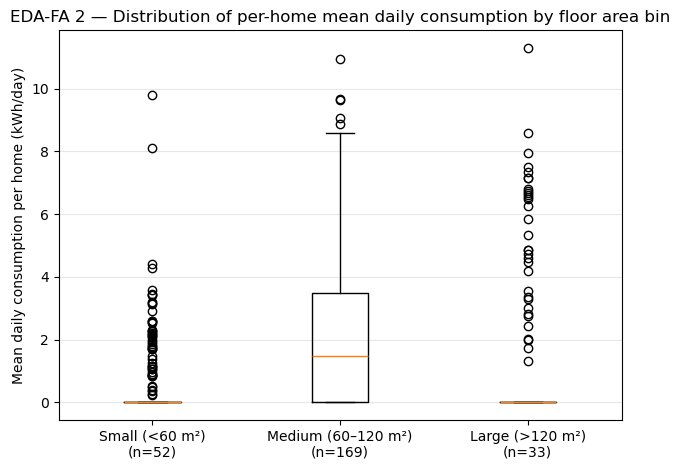

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_residents_floorarea\EDA_FA_02_mean_daily_kWh_boxplot_showfliers.png

Plots saved to: C:\IDEAL_Programming\processed\plots\eda_new\by_residents_floorarea


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
BASE_DIR = Path("C:/IDEAL_Programming")
DATA_PATH = BASE_DIR / "processed" / "final" / "IDEAL_final_hourly_dataset.csv"

# NEW folder (avoid mixing with old EDA)
PLOTS_DIR = BASE_DIR / "processed" / "plots" / "eda_new" / "by_floorarea"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Load
# =========================
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

need = ["home_id", "timestamp", "consumption_Wh", "total_floor_area_m2"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# =========================
# Floor area filter + bins
# =========================
df_fa = df[df["total_floor_area_m2"].notna()].copy()
df_fa["total_floor_area_m2"] = pd.to_numeric(df_fa["total_floor_area_m2"], errors="coerce")
df_fa = df_fa[df_fa["total_floor_area_m2"].notna()].copy()

bins = [0, 60, 120, 300]   # keep your max cap
labels = ["Small (<60 m²)", "Medium (60–120 m²)", "Large (>120 m²)"]

df_fa["floor_area_bin"] = pd.cut(
    df_fa["total_floor_area_m2"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Drop rows that failed binning (e.g., >300 or <=0)
before = len(df_fa)
df_fa = df_fa[df_fa["floor_area_bin"].notna()].copy()
after = len(df_fa)
print(f"Rows before bin filter: {before}, after: {after}, dropped: {before - after}")

# sanity: homes per bin + rows per bin
homes_per_bin = df_fa.groupby("floor_area_bin")["home_id"].nunique().reindex(labels)
rows_per_bin = df_fa["floor_area_bin"].value_counts().reindex(labels)
print("\nHomes per floor area bin:\n", homes_per_bin)
print("\nRows per floor area bin:\n", rows_per_bin)

def save_show(name: str):
    out = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# ==========================================================
# Plot 1: Mean hourly consumption by floor area bin (home-weighted)
# ==========================================================
plt.figure()

for b in labels:
    g = df_fa[df_fa["floor_area_bin"] == b]

    hw = (
        g.groupby(["home_id", "hour"])["consumption_Wh"].mean()
         .reset_index()
         .groupby("hour")["consumption_Wh"].mean()
         .sort_index()
    )

    plt.plot(hw.index, hw.values, marker="o", label=f"{b}\n(n={int(homes_per_bin.get(b, 0))})")

plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA-FA 1 — Mean hourly consumption by floor area bin (home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_FA_01_mean_consumption_by_hour_weighted.png")

# ==========================================================
# Plot 2: Distribution of per-home mean daily consumption by bin (kWh/day)
# ==========================================================
daily = (
    df_fa.groupby(["home_id", "floor_area_bin", "date"])["consumption_Wh"]
         .sum()
         .reset_index()
)

mean_daily = (
    daily.groupby(["home_id", "floor_area_bin"])["consumption_Wh"]
         .mean()
         .reset_index()
)
mean_daily["mean_daily_kWh"] = mean_daily["consumption_Wh"] / 1000.0

groups = [
    mean_daily.loc[mean_daily["floor_area_bin"] == b, "mean_daily_kWh"].values
    for b in labels
]
labels2 = [f"{b}\n(n={int(homes_per_bin.get(b, 0))})" for b in labels]

plt.figure()
plt.boxplot(groups, labels=labels2, showfliers=True)
plt.ylabel("Mean daily consumption per home (kWh/day)")
plt.title("EDA-FA 2 — Distribution of per-home mean daily consumption by floor area bin")
plt.grid(True, axis="y", alpha=0.3)
save_show("EDA_FA_02_mean_daily_kWh_boxplot_showfliers.png")

print("\nPlots saved to:", PLOTS_DIR)
